In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [2]:
from functools import partial

import numpy as np
from sklearn.datasets import make_moons, make_circles  # the synthetic dataset
import seaborn as sns


# in order to build our classifier we will use element from tensorflow along with
# layers from deel-lip
import keras
import keras.ops as K
from keras.layers import Input
from keras.optimizers import Adam

from deel.lip.model import Model  # not mandatory but offers the vanilla_export feature
from deel.lip.layers import SpectralDense, FrobeniusDense
from deel.lip.activations import GroupSort2
from deel.lip.losses import HKR, KR, HingeMargin  # custom losses for HKR robust classif

2025-07-18 16:13:52.854045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752848033.130836   14096 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752848033.206991   14096 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-18 16:13:53.922785: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
circle_or_moons = 1  # 0 for circle , 1 for moons
n_samples = 7000  # number of sample in the dataset
noise = 0.05  # amount of noise to add in the data. Tested with 0.14 for circles 0.05 for two moons
factor = 0.4  # scale factor between the inner and the outer circle

if circle_or_moons == 0:
    X, Y = make_circles(n_samples=n_samples, noise=noise, factor=factor)
else:
    X, Y = make_moons(n_samples=n_samples, noise=noise)

<Axes: >

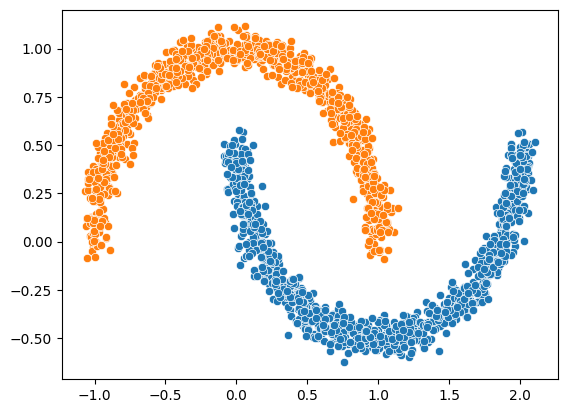

In [4]:

X1 = X[Y == 1]
X2 = X[Y == 0]
sns.scatterplot(x=X1[:1000, 0], y=X1[:1000, 1])
sns.scatterplot(x=X2[:1000, 0], y=X2[:1000, 1])
     

In [18]:
X_train = X[:5000]
Y_train = Y[:5000]

X_test = X[5000:]
Y_test = Y[5000:]

In [19]:
from keras.utils import to_categorical
Y_test = to_categorical(Y_test)
Y_train = to_categorical(Y_train)

In [20]:
Y_train.shape

(5000, 2)

In [21]:
batch_size = 256
steps_per_epoch = 40480
epoch = 10
hidden_layers_size = [256, 128, 64]  # stucture of the network
min_margin = 0.29  # minimum margin to enforce between the values of f for each class

In [22]:
keras.utils.clear_session()
# please note that calling the previous helper function has the exact
# same effect as the following code:
inputs = Input((2,))
x = SpectralDense(256, activation=GroupSort2())(inputs)
x = SpectralDense(128, activation=GroupSort2())(x)
x = SpectralDense(64, activation=GroupSort2())(x)
y = FrobeniusDense(1, activation=None)(x)
wass = Model(inputs=inputs, outputs=y)
wass.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_dense (SpectralDense)  │ (None, 256)            │         1,537 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_dense_1                │ (None, 128)            │        65,793 │
│ (SpectralDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_dense_2                │ (None, 64)             │        16,513 │
│ (SpectralDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frobenius_dense                 │ (None, 1)              │           129 │
│ (FrobeniusDense)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,972 (328.02 KB)

 Trainable params: 41,985 (164.00 KB)

 Non-trainable params: 41,987 (164.01 KB)

In [23]:
optimizer = Adam(learning_rate=0.01)

In [24]:
wass.compile(
    loss=HKR(
        alpha=10, min_margin=min_margin
    ),  # HKR stands for the hinge regularized KR loss
    metrics=[
        KR,  # shows the KR term of the loss
        HingeMargin(min_margin=min_margin),  # shows the hinge term of the loss
        keras.metrics.BinaryAccuracy(threshold=0),  # shows classif. accuracy
    ],
    optimizer=optimizer,
)

In [28]:
Y_train[:10]

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.]])

In [29]:
wass.predict(X_train[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[ 0.00697055],
       [-0.02549276],
       [ 0.00247958],
       [-0.00076849],
       [-0.10345934],
       [-0.03597687],
       [-0.00502259],
       [-0.03693043],
       [ 0.00458162],
       [-0.02178259]], dtype=float32)

In [27]:
wass.fit(X_train, Y_train, steps_per_epoch=steps_per_epoch // batch_size, epochs=epoch, verbose=1)

Epoch 1/10


158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - HingeMargin: 0.1570 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.5705
Epoch 2/10
 37/158 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - HingeMargin: 0.1509 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.5091

/home/aws_install/miniconda3/envs/k3tfenv/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1494 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.4939
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1479 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.4787
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1450 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.4500
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1450 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.4500
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1450 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.4500
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1450 - KR: 0.0000e+00 - binary_accuracy: 0.5000 - loss: 1.4500
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1450 - KR: 3.0035e-13 - binary_accuracy: 0.5000 - loss: 1.4500
Epoch 9/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - HingeMargin: 0.1450 - KR: 0.0000e